[*********************100%***********************]  1 of 1 completed


ADF p-value (raw): 0.9077
ADF p-value (diff): 0.0000

Performance:
Sharpe Ratio: -1.39
Max Drawdown: -7.15%


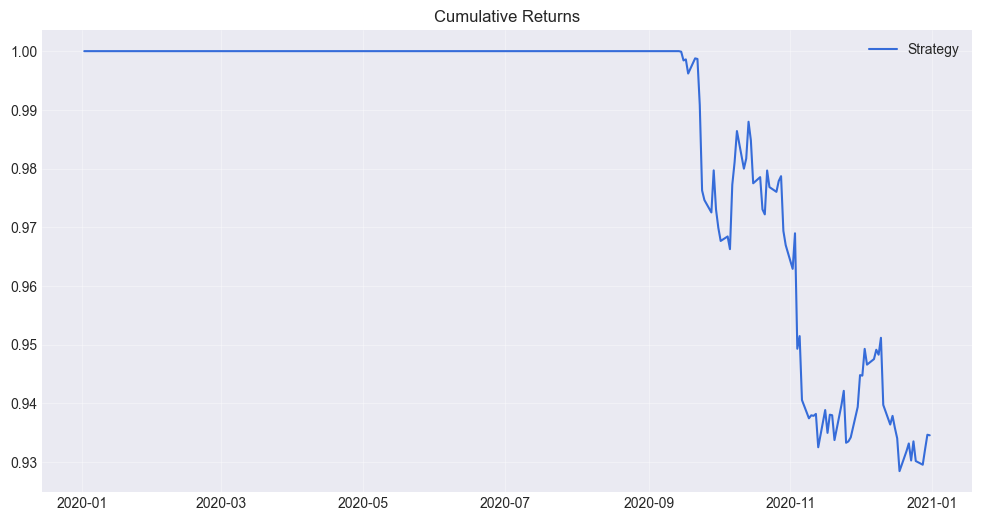

In [5]:
# =========================
# 1. IMPORT LIBRARIES
# =========================
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller

import warnings
warnings.filterwarnings("ignore")

plt.style.use('seaborn-v0_8-darkgrid')

# =========================
# 2. DOWNLOAD DATA
# =========================
# AUD/USD ticker
symbol = "AUDUSD=X"

data = yf.download(symbol, start="2020-01-01", end="2021-01-01", interval="1d",auto_adjust=False,multi_level_index=False)

# Clean
data = data[['Open', 'High', 'Low', 'Close', 'Volume']].dropna()
data.columns = ['open', 'high', 'low', 'close', 'volume']

# =========================
# 3. RESAMPLE TO 4H
# =========================
ohlcv_dict = {
    'open': 'first',
    'high': 'max',
    'low': 'min',
    'close': 'last',
    'volume': 'sum'
}

data = data.resample('4H').agg(ohlcv_dict).dropna()

# =========================
# 4. STATIONARITY CHECK
# =========================
result = adfuller(data['close'])
print(f"ADF p-value (raw): {result[1]:.4f}")

diff_series = data['close'].diff().dropna()
result = adfuller(diff_series)
print(f"ADF p-value (diff): {result[1]:.4f}")

# =========================
# 5. TRAIN WINDOW
# =========================
rolling_window = int(len(data) * 0.7)

# =========================
# 6. WALK-FORWARD ARIMA
# =========================
predictions = []

for i in range(rolling_window, len(data)):
    train = data['close'].iloc[i - rolling_window:i]

    try:
        model = ARIMA(train, order=(2, 1, 2))
        model_fit = model.fit()

        forecast = model_fit.forecast()[0]
    except:
        forecast = np.nan

    predictions.append(forecast)

# Align predictions
pred_series = pd.Series(predictions, index=data.index[rolling_window:])
data['predicted_price'] = pred_series

# Shift to avoid lookahead bias
data['predicted_price'] = data['predicted_price'].shift(1)

# =========================
# 7. SIGNAL GENERATION (FIXED)
# =========================
threshold = 0.0003

data['signal'] = np.where(
    (data['predicted_price'] - data['close']) > threshold, 1,
    np.where((data['predicted_price'] - data['close']) < -threshold, -1, 0)
)

# =========================
# 8. RETURNS
# =========================
data['returns'] = data['close'].pct_change()

# Transaction cost (important!)
cost = 0.0001

data['strategy_returns'] = (
    data['signal'].shift(1) * data['returns']
    - cost * abs(data['signal'].diff())
)

# =========================
# 9. PERFORMANCE METRICS
# =========================
strategy = data['strategy_returns'].dropna()

cum_returns = (1 + strategy).cumprod()

sharpe = np.sqrt(252) * strategy.mean() / strategy.std()
drawdown = (cum_returns / cum_returns.cummax() - 1).min()

print("\nPerformance:")
print(f"Sharpe Ratio: {sharpe:.2f}")
print(f"Max Drawdown: {drawdown:.2%}")

# =========================
# 10. PLOT RESULTS
# =========================
plt.figure(figsize=(12,6))
plt.plot(cum_returns, label="Strategy")
plt.title("Cumulative Returns")
plt.legend()
plt.show()